In [ ]:
#Importing Libraries
import os
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16 #import VGG16 
from tensorflow.keras.applications import DenseNet121 #import DenseNet121
from tensorflow.keras.applications.inception_v3 import InceptionV3 #import inceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten,GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import optimizers, losses
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from tensorflow.keras.models import load_model
import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [3]:
dataset_path = "/Users/User/Desktop/Tri2530/FYP 1/Fyp_model/kaggleFlowerDataset/flowers"

print("Folder exists:", os.path.exists(dataset_path))
print("Classes:", os.listdir(dataset_path))


Folder exists: True
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


## Display 2 image from each class

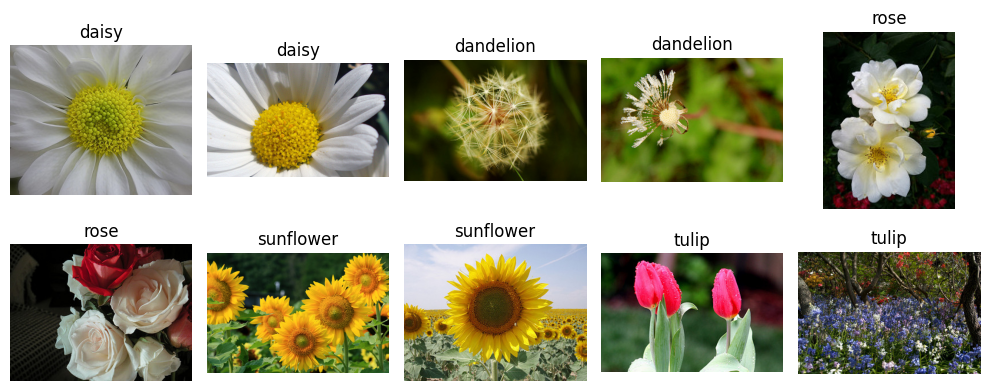

In [4]:
class_names = os.listdir(dataset_path)
class_names.sort()

plt.figure(figsize=(10, 10))

img_count = 1

for class_name in class_names:
    class_folder = os.path.join(dataset_path, class_name)
    images = os.listdir(class_folder)

    # take first 2 images from each class
    for i in range(2):
        img_path = os.path.join(class_folder, images[i])
        img = Image.open(img_path)

        ax = plt.subplot(len(class_names), 5, img_count)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)

        plt.title(class_name)
        plt.axis("off")

        img_count += 1

plt.tight_layout()
plt.show()

## Image resize

In [5]:
img_height = 224
img_width = 224
batch_size = 32

print(f"Dataset directory: {dataset_path}")
print(f"Target image dimensions: {img_height} x {img_width}")
print(f"Batch size: {batch_size}")

Dataset directory: /Users/User/Desktop/Tri2530/FYP 1/Fyp_model/kaggleFlowerDataset/flowers
Target image dimensions: 224 x 224
Batch size: 32


## Train test and Validation split

#### Full dataset 

In [6]:
full_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True
)

class_names = full_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)


Found 4317 files belonging to 5 classes.
Class names: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Number of classes: 5


In [ ]:
# Check the number of batches in the dataset
total_batches = tf.data.experimental.cardinality(full_ds).numpy()
print("Total batches:", total_batches)
# Split the dataset into training, validation, and test sets
train_size = int(0.8 * total_batches)
val_size = int(0.1 * total_batches)
#test_size = total_batches - train_size - val_size
train_ds = full_ds.take(train_size)
temp_ds = full_ds.skip(train_size)

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)


Total batches: 135


In [8]:
train_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches   = tf.data.experimental.cardinality(val_ds).numpy()
test_batches  = tf.data.experimental.cardinality(test_ds).numpy()

print("Train batches:", train_batches)
print("Val batches:", val_batches)
print("Test batches:", test_batches)

print("\nimage counts for:")

print("Train images :", train_batches * batch_size)
print("Val images :", val_batches * batch_size)
print("Test images :", test_batches * batch_size)


Train batches: 108
Val batches: 13
Test batches: 14

image counts for:
Train images : 3456
Val images : 416
Test images : 448


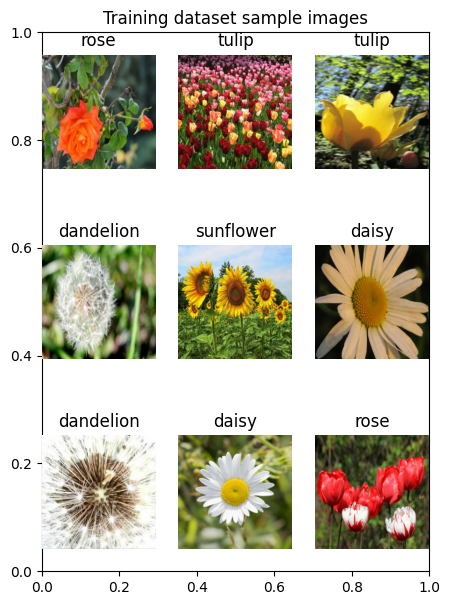

In [9]:
plt.figure(figsize=(5,7))
plt.title("Training dataset sample images")
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  # ✅ important
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

## Data Augmentation

In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),        # ~18 degrees
    tf.keras.layers.RandomTranslation(0.1, 0.1), # 10%
    tf.keras.layers.RandomZoom(0.1),
])


# Data Normalization

In [11]:
normalization_layer = tf.keras.layers.Rescaling(1./255)


In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(normalization_layer(x), training=True), y),
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)


In [13]:
val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)


## Compare Augmented image with original image 

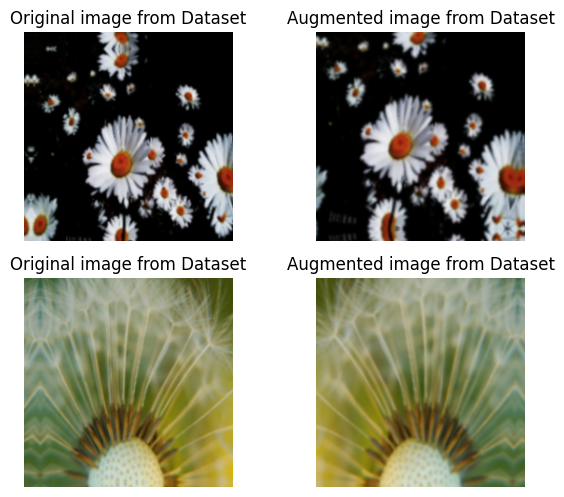

In [14]:
for images, labels in train_ds.take(1):
    original_images = images
    original_labels = labels

augmented_images = data_augmentation(original_images, training=True)

plt.figure(figsize=(6, 10))

for i in range(2):
    # Original
    ax = plt.subplot(4, 2, 2*i + 1)
    plt.imshow(original_images[i])
    plt.title("Original image from Dataset")
    plt.axis("off")

    # Augmented
    ax = plt.subplot(4, 2, 2*i + 2)
    plt.imshow(augmented_images[i])
    plt.title("Augmented image from Dataset")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Load VGG baseline model 

In [67]:
# Load the VGG16 model with pre-trained ImageNet weights
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

In [68]:
#freeze the base layer
base_model.trainable = False

vgg_model = base_model.output
vgg_model = Flatten()(vgg_model)
vgg_model = Dense(256,activation='relu')(vgg_model) # 256 neurons
vgg_model = Dropout(0.5)(vgg_model)
vgg_model = Dense(5,activation='softmax')(vgg_model)
vgg_model = Model(inputs=base_model.input,outputs=vgg_model)

In [69]:
#compile the model with optimize the performance of vgg16
vgg_model.compile(optimizer=Adam(learning_rate=0.00001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [70]:
vgg_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,757 (80.64 MB)

 Trainable params: 6,424,069 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [71]:
#train the model
epochs = 10

history = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)


Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 308s 3s/step - accuracy: 0.3617 - loss: 1.5136 - val_accuracy: 0.5986 - val_loss: 1.1335
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 298s 3s/step - accuracy: 0.5775 - loss: 1.1193 - val_accuracy: 0.6683 - val_loss: 0.9364
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 298s 3s/step - accuracy: 0.6386 - loss: 0.9742 - val_accuracy: 0.7067 - val_loss: 0.8185
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 296s 3s/step - accuracy: 0.6803 - loss: 0.8759 - val_accuracy: 0.7284 - val_loss: 0.7550
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 297s 3s/step - accuracy: 0.7043 - loss: 0.8180 - val_accuracy: 0.7644 - val_loss: 0.7081
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 297s 3s/step - accuracy: 0.7286 - loss: 0.7543 - val_accuracy: 0.7716 - val_loss: 0.6718
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 303s 3s/step - accuracy: 0.7309 - loss: 0.7388 - val_accuracy: 0.7716 - val_loss: 0.6457
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 297s 3s/step - accuracy: 0.7491 - loss: 0.7013 - val_accu

In [72]:
train_loss, train_acc = vgg_model.evaluate(train_ds)
val_loss, val_acc = vgg_model.evaluate(val_ds)

print("Training Loss:", round(train_loss, 4))
print("Training Accuracy:", round(train_acc * 100, 2), "%")

print("\nValidation Loss:", round(val_loss, 4))
print("Validation Accuracy:", round(val_acc * 100, 2), "%")


108/108 ━━━━━━━━━━━━━━━━━━━━ 276s 3s/step - accuracy: 0.8047 - loss: 0.5776
13/13 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.8005 - loss: 0.5822
Training Loss: 0.5776
Training Accuracy: 80.47 %

Validation Loss: 0.5822
Validation Accuracy: 80.05 %


In [73]:
test_loss, test_acc = vgg_model.evaluate(test_ds,verbose= 0)
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc * 100, 2), "%")

Test Loss: 0.6168
Test Accuracy: 78.2 %


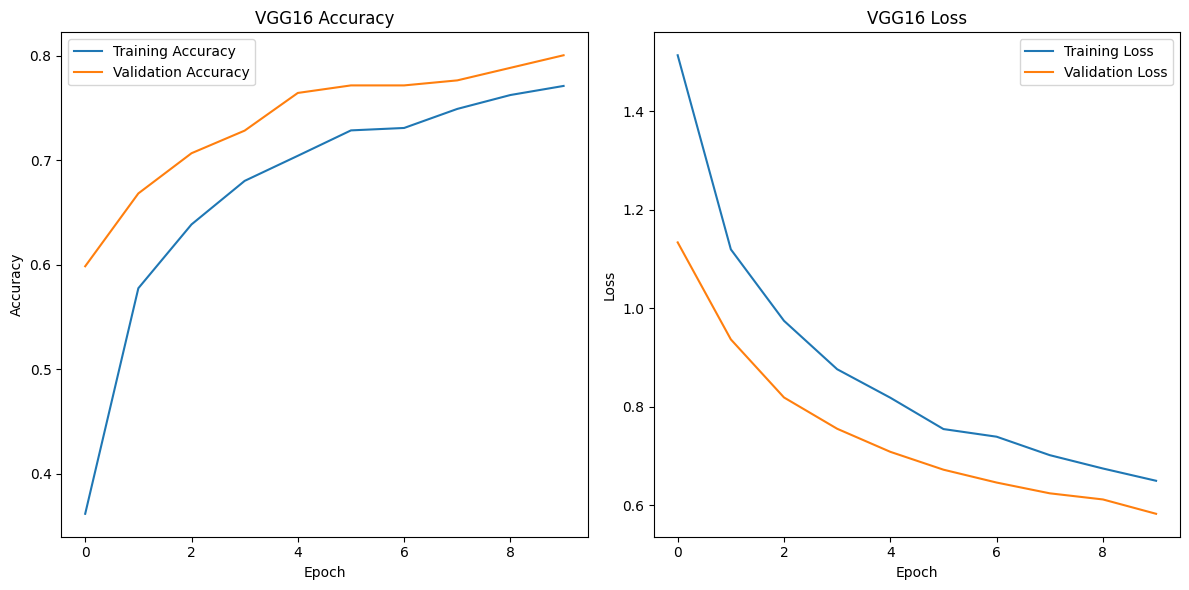

In [74]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("VGG16 Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG16 Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#Get Predictions from Test Set
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = vgg_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
print("\nClassification Output for Test set:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Classification Output for Test set:

              precision    recall  f1-score   support

       daisy       0.83      0.79      0.81        75
   dandelion       0.86      0.82      0.84        98
        rose       0.73      0.73      0.73        84
   sunflower       0.77      0.79      0.78        78
       tulip       0.74      0.78      0.76       110

    accuracy                           0.78       445
   macro avg       0.79      0.78      0.78       445
weighted avg       0.78  

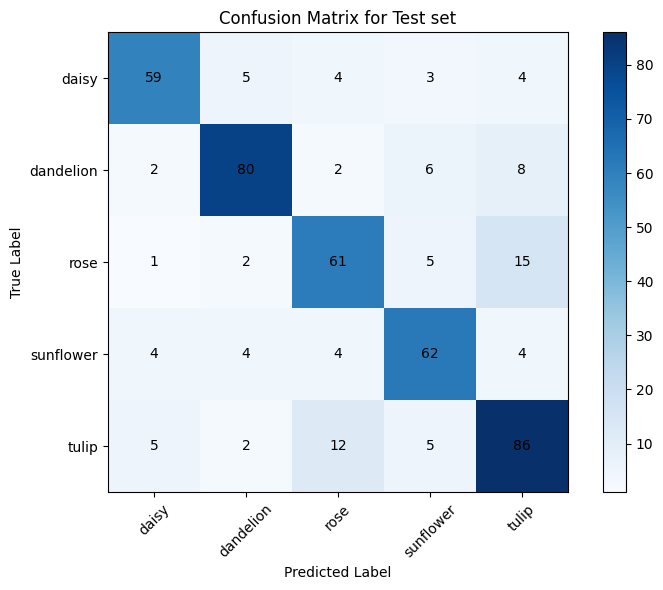

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm,cmap="Blues")
plt.title("VGG16 Confusion Matrix for Test set")
plt.colorbar()

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


### Inception V3 model

In [ ]:
base_inceptionV3 = tf.keras.applications.InceptionV3(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

#unfreeze the base layer
base_inceptionV3.trainable = True

for layer in base_inceptionV3.layers[:-50]:
    layer.trainable = False



In [91]:
model_inc = tf.keras.Sequential([
    base_inceptionV3,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(5, activation="softmax")
])


In [102]:
model_inc.compile(
    optimizer=tf.keras.optimizers.Adam(0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
    
)

In [103]:
model_inc.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_283         │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,329,637 (85.18 MB)

 Trainable params: 7,699,653 (29.37 MB)

 Non-trainable params: 14,629,984 (55.81 MB)

In [104]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [105]:
history_inc = model_inc.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks =[early_stop]
)

Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 109s 876ms/step - accuracy: 0.8229 - loss: 0.4759 - val_accuracy: 0.8750 - val_loss: 0.3782
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 104s 910ms/step - accuracy: 0.8400 - loss: 0.4573 - val_accuracy: 0.8918 - val_loss: 0.3625
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 110s 942ms/step - accuracy: 0.8495 - loss: 0.4221 - val_accuracy: 0.8918 - val_loss: 0.3511
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 99s 861ms/step - accuracy: 0.8655 - loss: 0.3742 - val_accuracy: 0.8966 - val_loss: 0.3458
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 100s 873ms/step - accuracy: 0.8600 - loss: 0.3909 - val_accuracy: 0.8942 - val_loss: 0.3351
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 98s 854ms/step - accuracy: 0.8683 - loss: 0.3687 - val_accuracy: 0.8966 - val_loss: 0.3281
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 99s 862ms/step - accuracy: 0.8683 - loss: 0.3684 - val_accuracy: 0.8990 - val_loss: 0.3196
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 101s 887ms/step - accuracy: 0.8860 - lo

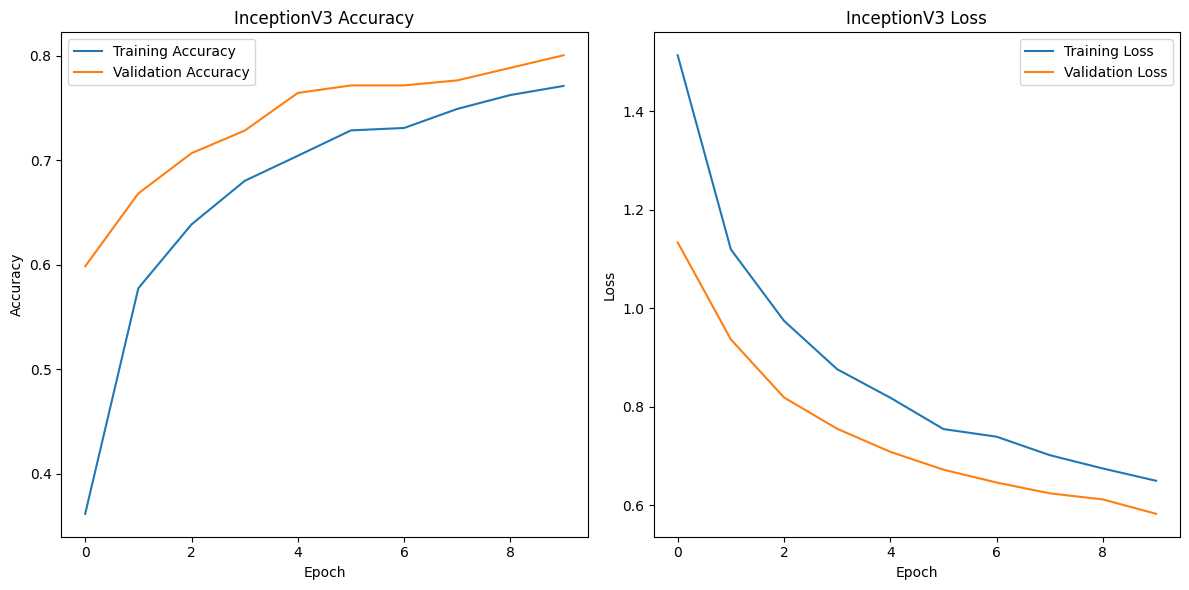

In [ ]:
plt.figure(figsize=(12, 6))
# need to re run
plt.subplot(1, 2, 1)
plt.plot(history_inc.history["accuracy"], label="Training Accuracy")
plt.plot(history_inc.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("InceptionV3 Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history_inc.history["loss"], label="Training Loss")
plt.plot(history_inc.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("InceptionV3 Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [106]:
train_loss_inc, train_acc_inc = model_inc.evaluate(train_ds)
val_loss_inc, val_acc_inc = model_inc.evaluate(val_ds)

print("Training Loss:", round(train_loss_inc, 4))
print("Training Accuracy:", round(train_acc_inc * 100, 2), "%")

print("\nValidation Loss:", round(val_loss_inc, 4))
print("Validation Accuracy:", round(val_acc_inc * 100, 2), "%")

108/108 ━━━━━━━━━━━━━━━━━━━━ 82s 713ms/step - accuracy: 0.9427 - loss: 0.1675
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 701ms/step - accuracy: 0.9159 - loss: 0.2961
Training Loss: 0.1675
Training Accuracy: 94.27 %

Validation Loss: 0.2961
Validation Accuracy: 91.59 %


In [108]:
test_loss_inc, test_acc_inc = model_inc.evaluate(test_ds,verbose= 0)
print("Test Loss:", round(test_loss_inc, 4))
print("Test Accuracy:", round(test_acc_inc * 100, 2), "%")

Test Loss: 0.4437
Test Accuracy: 86.52 %


In [112]:
#Get Predictions from Test Set
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model_inc.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
print("InceptionV3 Classification Output for Test set:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 652ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 659ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 645ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 653ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
InceptionV3 Classification Output for Test set:

              precision    recall  f1-score   support

       daisy       0.94      0.83      0.88        75
   dandelion       0.92      0.89      0.90        98
        rose       0.80      0.87      0.83        84
   sunflower       0.92      0.87      0.89        78
       tulip       0.80      0.86      0.83       110

    accuracy                           0.87       445
   macro avg       0.87      0.

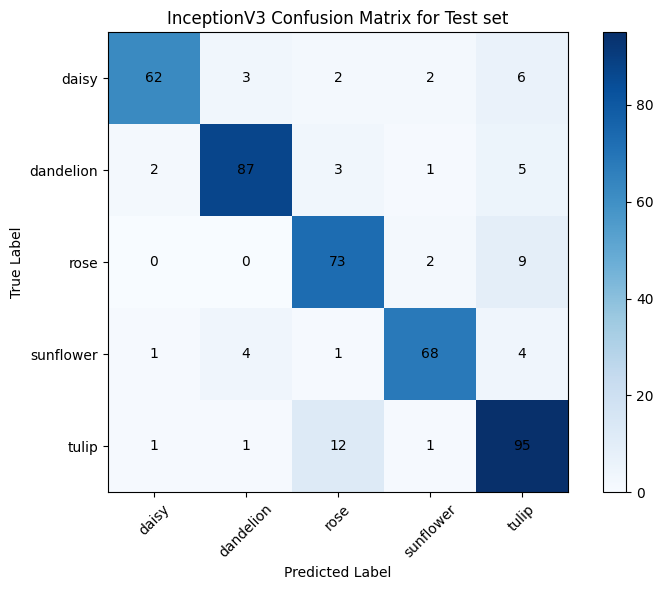

In [114]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm,cmap="Blues")
plt.title("InceptionV3 Confusion Matrix for Test set")
plt.colorbar()

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## DenseNet121

In [43]:
denseNet_base = DenseNet121(weights='imagenet', include_top=False, pooling='avg', input_shape=(img_height, img_width, 3))

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [44]:
denseNet_base.trainable = False

In [46]:
densenet_model = tf.keras.Sequential([
    denseNet_base,
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(5, activation="softmax")
])

In [ ]:
densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [48]:
densenet_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,302,213 (27.86 MB)

 Trainable params: 264,197 (1.01 MB)

 Non-trainable params: 7,038,016 (26.85 MB)

In [49]:
history_densenet = densenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.4980 - loss: 1.3957 - val_accuracy: 0.7644 - val_loss: 0.7156
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 0.7199 - loss: 0.7544 - val_accuracy: 0.8173 - val_loss: 0.4613
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 216s 2s/step - accuracy: 0.7775 - loss: 0.6173 - val_accuracy: 0.8534 - val_loss: 0.3855
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.8058 - loss: 0.5373 - val_accuracy: 0.8822 - val_loss: 0.3446
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.8244 - loss: 0.4833 - val_accuracy: 0.8870 - val_loss: 0.3244
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.8383 - loss: 0.4380 - val_accuracy: 0.9038 - val_loss: 0.3172
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.8414 - loss: 0.4256 - val_accuracy: 0.9111 - val_loss: 0.3132
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.8490 - loss: 0.4032 - val_accu

In [50]:
train_loss_densenet, train_acc_densenet = densenet_model.evaluate(train_ds)
val_loss_densenet, val_acc_densenet = densenet_model.evaluate(val_ds)

print("Training Loss:", round(train_loss_densenet, 4))
print("Training Accuracy:", round(train_acc_densenet * 100, 2), "%")

print("\nValidation Loss:", round(val_loss_densenet, 4))
print("Validation Accuracy:", round(val_acc_densenet * 100, 2), "%")

108/108 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.9106 - loss: 0.2551
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9087 - loss: 0.2881
Training Loss: 0.2551
Training Accuracy: 91.06 %

Validation Loss: 0.2881
Validation Accuracy: 90.87 %


In [51]:
test_loss_densenet, test_acc_densenet = densenet_model.evaluate(test_ds,verbose= 0)
print("Test Loss:", round(test_loss_densenet, 4))
print("Test Accuracy:", round(test_acc_densenet * 100, 2), "%")

Test Loss: 0.3413
Test Accuracy: 86.52 %


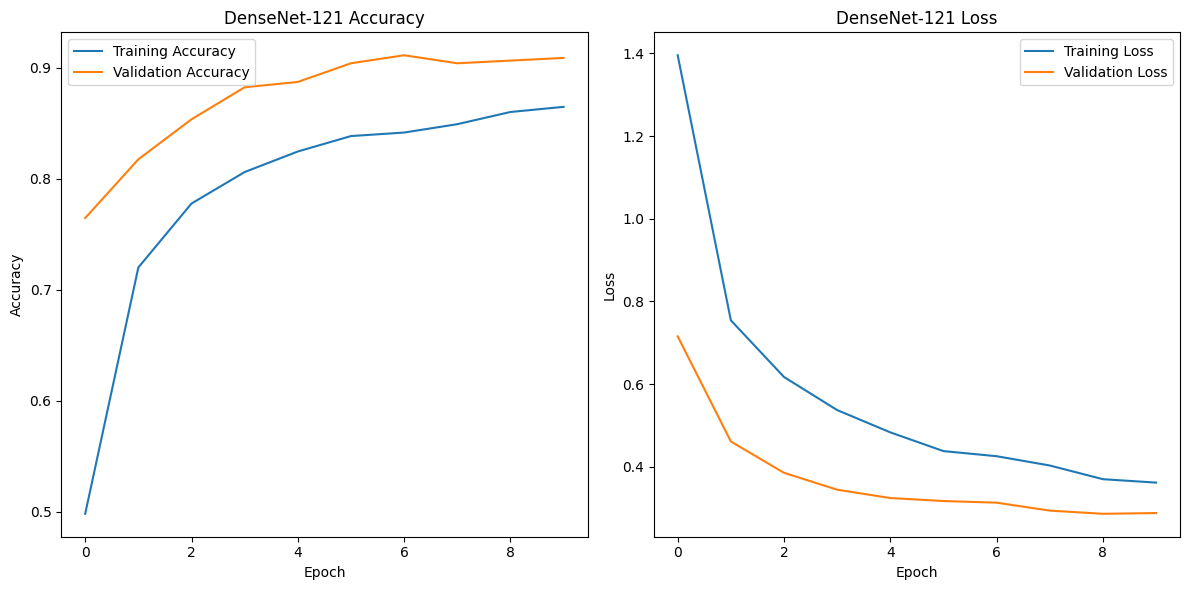

In [52]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history_densenet.history["accuracy"], label="Training Accuracy")
plt.plot(history_densenet.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("DenseNet-121 Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history_densenet.history["loss"], label="Training Loss")
plt.plot(history_densenet.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet-121 Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#Get Predictions from Test Set
y_true2 = []
y_pred2 = []

for images, labels in test_ds: #showing the predictions for each batch of test dataset
    predictions = densenet_model.predict(images)
    y_true2.extend(labels.numpy())
    y_pred2.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true2)
y_pred = np.array(y_pred2)
print("DenseNet-121 Classification Output for Test set:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
DenseNet-121 Classification Output for Test set:

              precision    recall  f1-score   support

       daisy       0.85      0.95      0.90        73
   dandelion       0.93      0.90      0.92       102
        rose       0.81      0.81      0.81        75
   sunflower       0.88      0.85      0.86        84
       tulip       0.84      0.83      0.84       111

    accuracy                           0.87       445
   macro avg       0.86      0.87      0.86       445
weighted avg

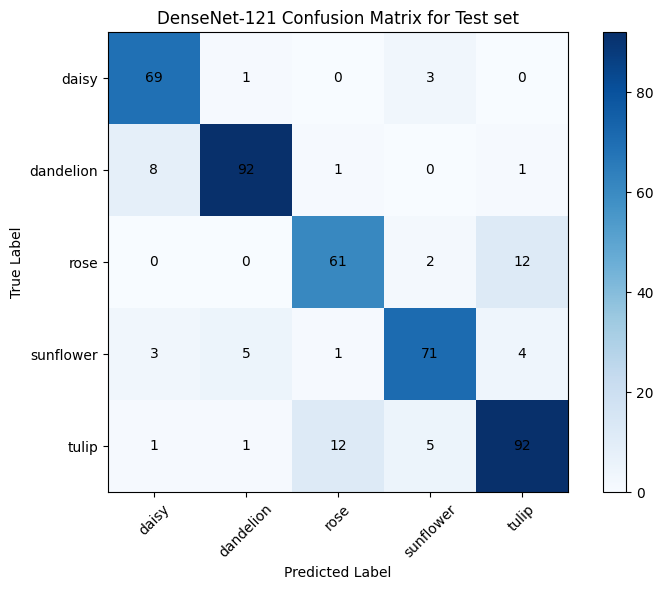

In [55]:
cm = confusion_matrix(y_true2, y_pred2)

plt.figure(figsize=(8, 6))
plt.imshow(cm,cmap="Blues")
plt.title("DenseNet-121 Confusion Matrix for Test set")
plt.colorbar()

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()